<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Evaluating_NLP_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
jeffpoulshaju_modeling_with_xgboost_path = kagglehub.notebook_output_download('jeffpoulshaju/modeling-with-xgboost')

print('Data source import complete.')


Extracting files...
Data source import complete.


# Evaluating NLP Models

Welcome to the final notebook of the **Intro to NLP** Learn Guide! In the previous step, we successfully trained an XGBoost model to recognize the mathematical patterns of spam. Now, we need to see how well it actually performs.

In this notebook, we will only be focusing on evaluating this specific model. If you want to learn more about model evaluation in detail, be sure to check out the **[Model Evaluation](https://www.kaggle.com/learn-guide/model-evaluation)** Learn Guide!

To get started, we will bring in the testing data and the official predictions we saved during our last session.

In [3]:
import numpy as np
import joblib

# Set your Kaggle input path using the name of your third notebook
base_path = jeffpoulshaju_modeling_with_xgboost_path

# Load the actual answers and the model predictions
y_test = np.load(base_path + '/y_test.npy')
y_pred = np.load(base_path + '/y_pred.npy')

# Load the trained XGBoost model
model = joblib.load(base_path + '/xgboost_spam_model.pkl')

print("Data and model loaded successfully! Ready to evaluate performance.")

Data and model loaded successfully! Ready to evaluate performance.


/usr/lib/python3.12/pickle.py:1760: UserWarning: [14:45:49] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


## The Confusion Matrix

When evaluating any classification model, the absolute best place to start is the Confusion Matrix.

Instead of just giving us a single, vague score, a confusion matrix visually breaks down exactly what our model got right and what it got wrong. It is a 2x2 grid that maps our model's predictions against the actual real-world answers. By analyzing how the model is confused, we gain deep insight into its performance.

![](https://github.com/jeffpoulshaju/Model-evaluation/raw/ce18be9eab0fe350884a33530df5cba30c5befda/cours%20img.png)

The grid is divided into four distinct boxes, representing the four possible outcomes of a classification task.

* **True Positive:** In the context of our spam filter, this happens when the model correctly identifies a junk message. The model *predicted the text was spam, and it actually was spam*, meaning the junk was successfully caught.

* **True Negative:** This occurs when the model correctly identifies a normal, everyday text. The algorithm *predicted the message was safe, and the real world confirmed it was a genuine message.* Together with True Positives, these two boxes represent everything our model got perfectly right.

* **False Positive (Type I Error) :** This is when the *model predicts a message is spam, but it was actually a legitimate text.* In our project, this means an important email was accidentally sent to the junk folder. As we discussed earlier, this is usually the most frustrating error for a user to experience because it blocks real communication.

* **False Negative (Type II Error) :** This happens when the *model predicts a message is normal, but it was actually spam.* The filter failed to catch the junk, allowing it to slip right into the main inbox. By analyzing all four of these outcomes together, we can see exactly where our algorithm struggles and where it excels.

Let's now generate the confusion matrix for our data using the code below.

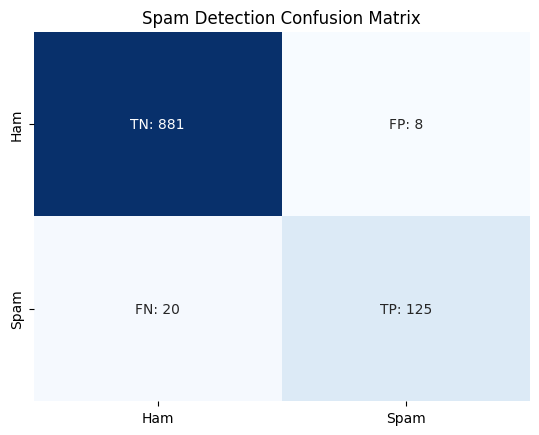

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the matrix and define the labels in a compact format
cm = confusion_matrix(y_test, y_pred)
labels = [[f"TN: {cm[0,0]}", f"FP: {cm[0,1]}"], [f"FN: {cm[1,0]}", f"TP: {cm[1,1]}"]]

# Plot the heatmap
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
plt.title('Spam Detection Confusion Matrix')
plt.show()

## Accuracy

Using the values from our newly generated confusion matrix, we can easily calculate our overall accuracy. This metric acts as the final grade for our model, asking exactly how many predictions it got right.

$$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$

Running the Python code below will crunch these exact numbers for us. As you will see in the output, combining our true positives and true negatives shows our model correctly predicted whether a message was spam or ham 97.29 percent of the time, giving us an impressive final score of 0.9729. With this solid baseline established, we can now move on to our remaining performance metrics.

In [5]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy by comparing our pre-loaded predictions to the true answers
test_accuracy = accuracy_score(y_test, y_pred)

# Print the final score formatted as a percentage
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9729206963249516


## Other Performance Metrics

Let's look at the math behind these metrics. We've included our actual scores for our spam filter as a sneak peek before diving into the Python code below!

1. **Precision (The "Quality" of our Alarms)** $$Precision=\frac{TP}{TP+FP}$$

   *What it asks:* Out of all the messages our model *claimed* were spam, how many actually were? This metric severely punishes Type I Errors (False Positives).

   *Our Score:* 0.94 (94%). When our model confidently declares "This is spam!", it is correct 94% of the time. The other 6% of the time, it was a false alarm (a normal message sent to the junk folder).

2. **Recall (The Safety Net)** $$Recall=\frac{TP}{TP+FN}$$

   *What it asks:* Out of all the actual spam messages in the dataset, what percentage did our model successfully find? This metric severely punishes Type II Errors (False Negatives).

   *Our Score:* 0.86 (86%). Our model successfully caught 86% of the real spam. Unfortunately, 14% of the spam slipped through the cracks and landed in the main inbox.

4. **F1-Score (The Compromise)** $$F_1=2\times\frac{Precision\times Recall}{Precision+Recall}$$

   *What it asks:* Can we find a fair, mathematical middle ground between Precision and Recall?

   *Our Score:* 0.90. It is mathematically very hard to have perfect Precision and perfect Recall at the same time. If we cast a wider net to catch all spam (high Recall), we will inevitably scoop up some normal messages (lower Precision). The F1-score calculates the harmonic mean of the two, giving us a single, balanced metric to judge our model's true effectiveness.

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate and print the advanced classification metrics
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))

Precision: 0.9398496240601504
Recall:    0.8620689655172413
F1 Score:  0.8992805755395683


## Interpreting Our Results

Now that we have calculated all our metrics, what do they actually mean for our new spam filter? It is very tempting to just look at a high Accuracy score and call it a day, but in the real world of machine learning, the context of our errors matters immensely.

This is exactly why we must carefully weigh Recall against Precision. **While it might seem ideal to push our Recall as high as possible so that absolutely no spam ever reaches the inbox, pursuing that perfection comes at a steep cost.** If our model becomes too aggressive at catching spam, it will inevitably start misclassifying normal, important emails as junk. Missing an urgent message from a colleague because your filter made a mistake is a much worse experience than occasionally having to manually delete a junk email that slipped through. Because of this, **developers building spam detectors typically favor a higher Precision to protect the user's primary inbox from false alarms.**

By looking at our final F1 Score of 0.90, we can confidently say our model struck a highly effective mathematical balance. It successfully caught the vast majority of the junk mail while keeping false alarms to a strict minimum. From cleaning raw text to evaluating advanced performance metrics, you have successfully built and tested a robust natural language processing pipeline.

## What's Next?

**Congratulations on completing this Learn Guide!** We have officially evaluated our model and completed the entire beginner NLP pipeline! If you feel like you have a solid grasp of these foundational concepts, it is time to move up to the intermediate level.

To tackle more advanced techniques and build even smarter models, you can continue your journey by jumping directly into the [**Intermediate Natural Language Processing**](https://www.kaggle.com/learn-guide/intermediate-nlp) Learn Guide.